In [1]:
import maboss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splrep, BSpline
from scipy.special import logit, expit
from scipy.optimize import curve_fit
import math, mpmath

In [2]:
def get_TDC_ratio(popstate):
    tcell = 0
    dc = 0
    for population in popstate[1:-1].split(","):
        if len(population) > 2:
            states, pop = population[1:-1].split(":")
            if states != "<nil>":
                list_states = states.split(" -- ")
                try:
                    if "DC" in list_states and "TCell" not in list_states:
                        dc += int(pop)
                    
                    elif "TCell" in list_states:
                        tcell += int(pop)
                except:
                    print(pop)
    return None if (tcell == 0 or dc == 0) else tcell/dc

In [3]:
def cubic(list_x, a, b, c, d):
    return [a*x**3 + b*x**2 + c*x + d for x in list_x]

### Simulation with pyMaBoSS

In [4]:
folder = "ICD_phenomenological/res_icd_1.1"

In [5]:
sim_long = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig.cfg")
res_long = sim_long.run(workdir=folder, prefix="ResICD_phenLong")

In [6]:
sim_long5Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig5CExp.cfg")
res_long5Cl = sim_long5Cl.run(workdir=folder, prefix="ResICD_phenLong5ClExp")

In [7]:
sim_long10Cl = maboss.PopSimulation("ICD_phenomenological/ICD_phenomenologicalPM.pbnd", "ICD_phenomenological/ICD_phenomenologicalPMNewICBig10CExp.cfg")
res_long10Cl = sim_long10Cl.run(workdir=folder, prefix="ResICD_phenLong10ClExp")

In [8]:
serie = res_long.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie5Cl = res_long5Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)
serie10Cl = res_long10Cl.get_state_dist_by_index(11*24+1, get_TDC_ratio)

/tmp/ipykernel_391166/3142884951.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


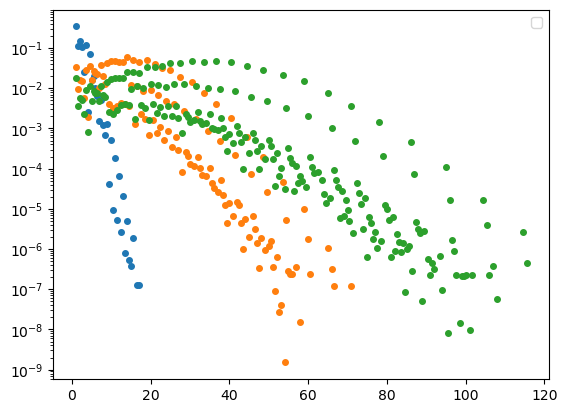

In [23]:
serie.plot(logy=True, marker='o', markersize=4, color='C0', linestyle="None")
serie5Cl.plot(marker='o', markersize=4, color='C1', linestyle="None")
serie10Cl.plot(marker='o', markersize=4, color='C2', linestyle="None")
plt.legend()

In [10]:
spline = splrep(serie.index, serie.values)
spline5Cl = splrep(serie5Cl.index, serie5Cl.values)
spline10Cl = splrep(serie10Cl.index, serie10Cl.values)

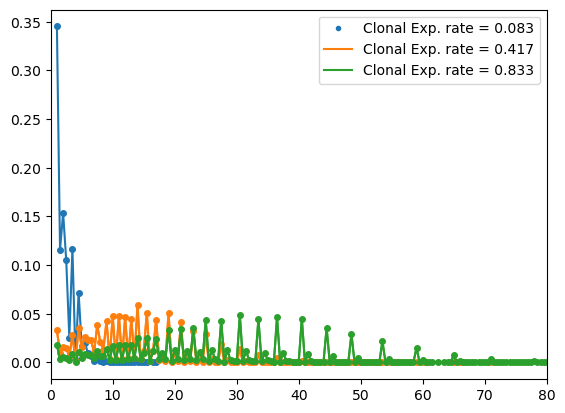

In [11]:
serie.plot(marker='o', markersize=4, color='C0')
plt.plot(serie.index, BSpline(*spline)(serie.index), '.', color='C0', label=('Clonal Exp. rate = %.3f' % (1/12)))

serie5Cl.plot(marker='o', markersize=4, color='C1')
plt.plot(serie5Cl.index, BSpline(*spline5Cl)(serie5Cl.index), '-', color='C1', label=('Clonal Exp. rate = %.3f' % (5/12)))

serie10Cl.plot(marker='o', markersize=4, color='C2')
plt.plot(serie10Cl.index, BSpline(*spline10Cl)(serie10Cl.index), '-', color='C2', label=('Clonal Exp. rate = %.3f' % (10/12)))

plt.xlim([0,80])
plt.legend()

In [12]:
splineLogit = splrep(serie.index, logit(serie.values))
splineLogit5Cl = splrep(serie5Cl.index, logit(serie5Cl.values))
splineLogit10Cl = splrep(serie10Cl.index, logit(serie10Cl.values))

In [13]:
splineLogitFunc = BSpline(*splineLogit)
splineLogitFunc5Cl = BSpline(*splineLogit5Cl)
splineLogitFunc10Cl = BSpline(*splineLogit10Cl)

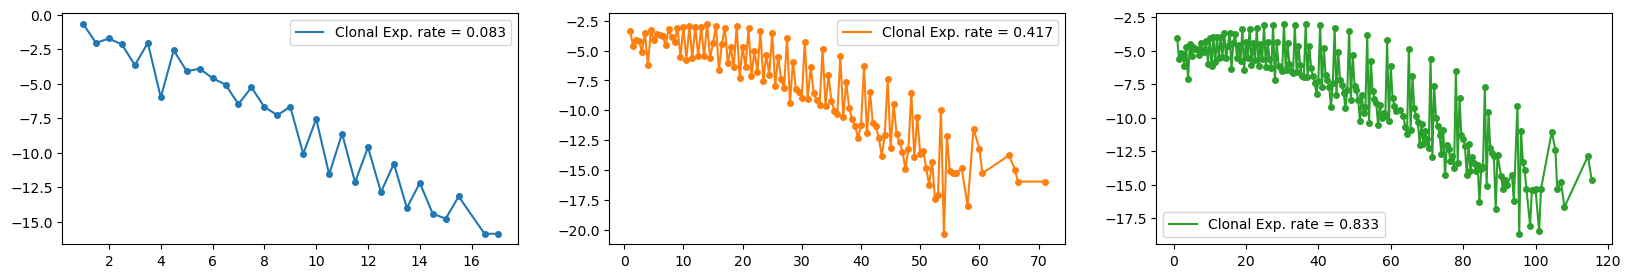

In [14]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index, splineLogitFunc(serie.index), marker=None, color='C0', label=('Clonal Exp. rate = %.3f' % (1/12)), linestyle='-')
ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, splineLogitFunc5Cl(serie5Cl.index), marker=None, color='C1', label=('Clonal Exp. rate = %.3f' % (5/12)), linestyle='-')
ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, splineLogitFunc10Cl(serie10Cl.index), marker=None, color='C2', label=('Clonal Exp. rate = %.3f' % (10/12)), linestyle='-')
ax[2].legend()

In [15]:
serie.values

array([3.45199138e-01, 1.15949223e-01, 1.53570713e-01, 1.05075285e-01,
       2.54446261e-02, 1.16784192e-01, 2.50169058e-03, 7.18784694e-02,
       1.65194817e-02, 1.98842941e-02, 1.00870994e-02, 6.29648314e-03,
       1.54186722e-03, 5.18574095e-03, 1.25291869e-03, 6.93136331e-04,
       1.27003212e-03, 4.18779559e-05, 5.27745986e-04, 9.44761995e-06,
       1.81960042e-04, 5.33098175e-06, 6.71699284e-05, 2.59635568e-06,
       2.05482973e-05, 8.18423940e-07, 5.05228064e-06, 5.40442798e-07,
       3.77921648e-07, 1.88960824e-06, 1.25973883e-07, 1.25973883e-07])

In [16]:
popt, _ = curve_fit(cubic, serie.index[1:], logit(serie.values[1:]))
popt5Cl, _ = curve_fit(cubic, serie5Cl.index[1:], logit(serie5Cl.values[1:]))
popt10Cl, _ = curve_fit(cubic, serie10Cl.index[1:], logit(serie10Cl.values[1:]))

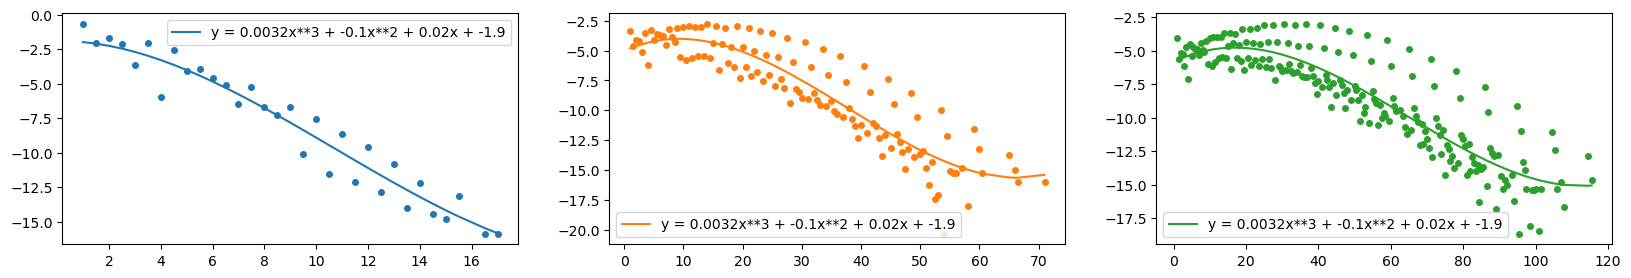

In [17]:
fig, ax = plt.subplots(1,3, figsize=(20,3))
ax[0].plot(serie.index, logit(serie.values), marker='o', markersize=4, color='C0', linestyle='None')
ax[0].plot(serie.index, cubic(serie.index, *popt), marker=None, color='C0', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[0].legend()

ax[1].plot(serie5Cl.index, logit(serie5Cl.values), marker='o', markersize=4, color='C1', linestyle='None')
ax[1].plot(serie5Cl.index, cubic(serie5Cl.index, *popt5Cl), marker=None, color='C1', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[1].legend()

ax[2].plot(serie10Cl.index, logit(serie10Cl.values), marker='o', markersize=4, color='C2', linestyle='None')
ax[2].plot(serie10Cl.index, cubic(serie10Cl.index, *popt10Cl), marker=None, color='C2', label=("y = %.2gx**3 + %.2gx**2 + %.2gx + %.2g" % (*popt,)), linestyle='-')
ax[2].legend()

In [18]:
exp_data = pd.read_csv("ICD_phenomenological/TratioDC.csv", sep="\t")
exp_data_filtered = exp_data[(exp_data["Day"] == 11) & (exp_data["Treatment"] == "MTX")]["TratioDC"]

In [19]:
log_likelyhood = np.log(np.prod(expit(BSpline(*splineLogit)(exp_data_filtered))))
log_likelyhood5Cl = np.log(np.prod(expit(BSpline(*splineLogit5Cl)(exp_data_filtered))))
log_likelyhood10Cl = np.log(np.prod(expit(BSpline(*splineLogit10Cl)(exp_data_filtered))))

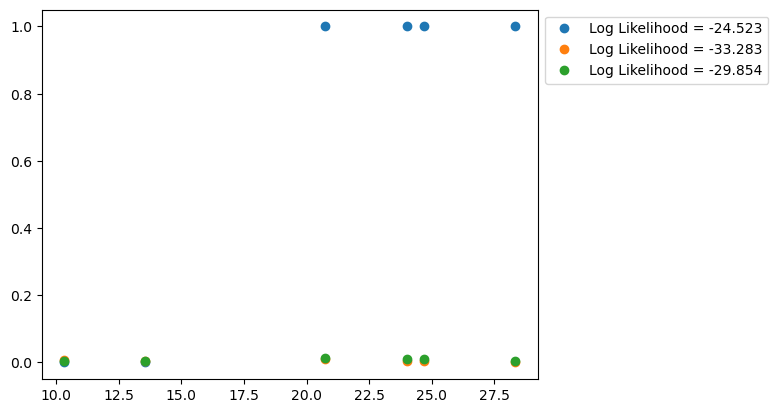

In [20]:
plt.plot(exp_data_filtered.values, expit(splineLogitFunc(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc5Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(splineLogitFunc10Cl(exp_data_filtered)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))

In [21]:
log_likelyhood = np.log(np.prod(expit(cubic(exp_data_filtered, *popt))))
log_likelyhood5Cl = np.log(np.prod(expit(cubic(exp_data_filtered, *popt5Cl))))
log_likelyhood10Cl = np.log(np.prod(expit(cubic(exp_data_filtered, *popt10Cl))))

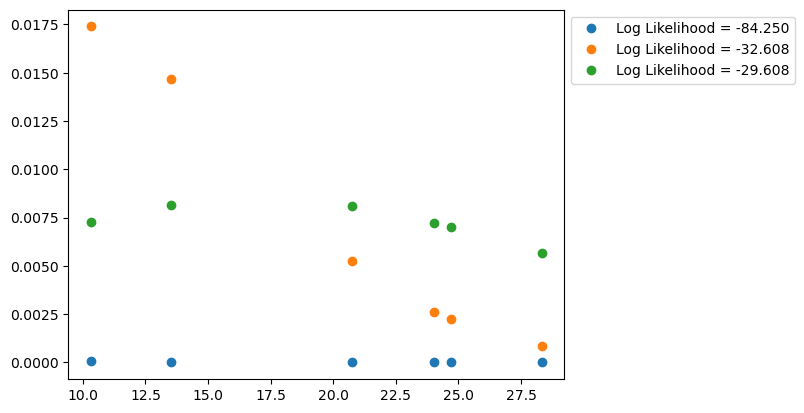

In [22]:
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood))
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt5Cl)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood5Cl))
plt.plot(exp_data_filtered.values, expit(cubic(exp_data_filtered, *popt10Cl)), 'o', label=("Log Likelihood = %.3f" % log_likelyhood10Cl))
plt.legend(loc='upper left', bbox_to_anchor=(1., 1.))